# Small-Scale ERP Image Classification

This notebook studies how far very small ERP images can go in a binary classification setting (`sigmoid` vs `no_class`).
The goal is not only to compare models, but to make the full chain explicit:

- how simulator settings are chosen
- why those settings are considered plausible or useful
- how downstream classifiers behave on the real labeled fixation dataset
- where the model succeeds and fails on concrete examples

This notebook focuses on the **simulator-first search workflow**.
The model-first Dense-NN low-pass direct search now lives in the companion notebook `dense_nn_lowpass_direct_search.ipynb` in the same folder.

1. **Simulator-first search (original workflow)**
   A simulation parameter search is run first. The search methods are `broad_random`, `lhs_calibrated`, and `mc_random_search`.
   In this workflow, candidate simulator settings are scored with a **proxy matching objective** that compares simulated `sigmoid` images to real `sigmoid` images in feature space.
   Only after that search do we generate larger simulated datasets, train several models, and rank the final downstream results on real data.

Companion workflow:
- `dense_nn_lowpass_direct_search.ipynb` runs `broad_random`, `latin_hypercube`, and `monte_carlo` directly against real-data Dense-NN `balanced_accuracy`
- it starts from `base_cfg` only and does not reuse top settings from this notebook

Typical reading order:
- run the environment setup once after opening the notebook
- adjust the shared experiment controls
- run the original simulator-first workflow
- inspect the summary table, ranked table, and representative settings table
- inspect concrete TP / TN / FP / FN examples to understand actual behavior
- open `dense_nn_lowpass_direct_search.ipynb` separately if you want the model-first follow-up optimization

Why this notebook is structured this way:
- it keeps the broad simulator-first comparison and diagnostics together
- the more expensive task-driven Dense-NN optimization is isolated in its own notebook
- the diagnostic sections are there so the notebook is not only an optimization script, but also an analysis document

Note:
The labeled real `sigmoid` / `no_class` examples in this repository come from the fixation dataset plus Label Studio annotations.


## Environment Setup

Run the next cell once after opening the notebook or restarting the Julia kernel.

What it does:
- activates the relevant Julia project
- loads the simulation and ERP-image helper modules
- imports plotting, ML, and data-handling packages used later
- prints a small environment sanity check

Why this matters:
- almost every later section depends on these helper definitions
- if package activation or helper loading is broken, it is better to fail here than deep inside an expensive experiment run


In [1]:
# Environment setup for the notebook.
# Run this once after opening the notebook or restarting the kernel.
#
# Why this cell exists:
# - it activates the Julia project that contains the simulation dependencies
# - it loads the helper module used by nearly every later section
# - it prints a few environment checks so you can see immediately whether CUDA is available
#
# If this cell fails, later sections will usually fail as well, so it is the right first debugging point.
import Pkg

ENV["JULIA_PKG_PRECOMPILE_AUTO"] = "0"
ENV["JULIA_NUM_PRECOMPILE_TASKS"] = "1"

Pkg.activate(joinpath(pwd(), "..", "data_generation"))

using Flux
using MLUtils
using StatsBase
using CairoMakie
using Random
using Distributions
using Statistics
using DecisionTree
using LIBSVM
using CUDA
using cuDNN
using CSV
using DataFrames
using HDF5

if !isdefined(Main, :ERPGen)
    include(joinpath(pwd(), "..", "data_generation", "erpgen.jl"))
end
using .ERPGen

if !isdefined(Main, :ERPImageUtils)
    include(joinpath(pwd(), "..", "utils", "erp_image_utils.jl"))
end
using .ERPImageUtils

include(joinpath(pwd(), "simulation_small_scale_helpers.jl"))
using .SmallScaleERPClassification

println("Active project: ", Base.active_project())
println("Flux version: ", Base.pkgversion(Flux))
println("CUDA functional: ", CUDA.functional())


  Activating project at `~/Dokumente/BA2/notebooks/data_generation`


Active project: /home/benjamin/Dokumente/BA2/notebooks/data_generation/Project.toml
Flux version: 0.16.9
CUDA functional: true


## Experiment Controls

Edit the next code cell before launching the heavy run. This cell defines the global budget and determines how expensive the original workflow will be.

What you should do here:
- decide how much compute you want to spend
- decide which resolutions and preprocessing conditions matter for your comparison
- decide how aggressive the simulator search should be before model training starts

Why this matters:
- the simulator-first workflow has two separate cost drivers: **search cost** and **downstream model-training cost**
- if these are not set consciously, it becomes hard to interpret whether weak results come from a weak simulator, too little simulated data, or undertrained models

### Parameter space dimensionality

The simulator currently exposes **24 parameter specifications** (each with a mean and a standard deviation), resulting in a **48-dimensional search space**.
These include the original ERP component widths, gaps, amplitudes, and noise levels, plus the newer basis-shape parameters:

- `tilted_bar_hanning_length`: controls the Hanning envelope width in the tilted-bar pattern
- `one_sided_fan_duration_divisor`, `one_sided_fan_log_mu_offset`, `one_sided_fan_log_sigma`, `one_sided_fan_support_max`: control the lognormal basis function of the one-sided-fan pattern

For a 48-dimensional space, 18 random candidates provide extremely sparse coverage.
As a rule of thumb, `CALIBRATION_CANDIDATES` should be at least comparable to the parameter dimension (i.e., >= 50).

### Important controls in the original workflow

- `BASE_SEED`
  Runtime-generated random seed based on `time_ns()`. Re-running the cell creates a fresh seed for the full workflow.
  This is useful when you want a new stochastic run instead of reproducing the previous one exactly.

- `TARGET_SIZES`
  The ERP image resolutions that will be evaluated. In this notebook the comparison is intentionally small-scale: `2x2`, `4x4`, `8x8`, and `16x16`.
  These sizes test how much information survives aggressive downsampling.

- `LOWPASS_CHOICES`
  Whether a low-pass style prefilter is applied before resizing.
  This matters because strong downsampling without smoothing can create aliasing and distort ERP structure.

- `STRATEGY_NAMES`
  The simulation-search strategies that will be executed:
  - `:broad_random`: random settings drawn from the broad global parameter ranges
  - `:lhs_calibrated`: Latin hypercube sampling over the global ranges, then keep the best candidates
  - `:mc_random_search`: Monte Carlo random sampling over the global ranges, then keep the best candidates

- `CALIBRATION_CANDIDATES`
  The number of parameter candidates evaluated **per calibrated search method** in the original workflow.
  With a 48-dimensional parameter space, values below 50 leave the search very sparse.
  Higher values (50-100) give the proxy-based search better coverage at moderate extra cost.

- `CALIBRATION_TOP_K`
  After scoring all candidates in `lhs_calibrated` and `mc_random_search`, only the top `K` settings are retained and used to generate the larger simulated datasets.
  This matters because the final strategy datasets are mixtures of retained settings, not single isolated runs.

- `PROBE_N_PER_PATTERN`
  Number of simulated examples per class used during the **small proxy calibration probe**.
  This controls the cost and stability of the simulator-matching stage before full model training starts.

- `N_PER_PATTERN`
  Number of repetitions per pattern used when the final simulated training datasets are built for each strategy.
  Larger values give the downstream models more simulated training data, but also increase runtime and memory usage.
  Note: this should be consistent with `NN_DIRECT_N_PER_PATTERN` in `dense_nn_lowpass_direct_search.ipynb` to keep both workflows comparable.

- `NN_BATCH_SIZE`, `NN_EPOCHS`, `NN_LR`, `RF_TREES`
  Downstream model-training hyperparameters used after the simulator settings have been selected.
  These do not change the simulator directly, but they change how well the downstream learner can exploit the simulated data.

Rule of thumb:
- If you want to spend more compute on the **original proxy-guided search**, first increase `CALIBRATION_CANDIDATES`.
- If you want to spend more compute on the **final downstream training**, increase `N_PER_PATTERN` or `NN_EPOCHS`.
- If results fluctuate strongly between runs, first increase `PROBE_N_PER_PATTERN` or `NN_LOWPASS_SEARCH_EVAL_REPEATS` before drawing conclusions about parameter quality.


In [2]:
# Shared experiment controls.
#
# What to do here:
# - change the budget numbers before running the main experiment cell
# - leave the later cells untouched unless you specifically want to change the analysis logic
#
# Why this cell is separate:
# - it keeps the expensive run configuration in one place
# - it makes reruns easier because you can change the budget without editing the helper code
#
# Note on CALIBRATION_CANDIDATES:
# The simulator now has 24 parameter specs (48 dimensions including mean + std).
# 18 candidates was too sparse for this space. 50 gives ~1 candidate per dimension,
# which is a reasonable minimum for LHS/MC proxy-based search.
BASE_SEED = Int(time_ns())

TARGET_SIZES = SmallScaleERPClassification.TARGET_SIZES
LOWPASS_CHOICES = SmallScaleERPClassification.LOWPASS_CHOICES
STRATEGY_NAMES = [:broad_random, :lhs_calibrated, :mc_random_search]

N_PER_PATTERN = 1000
CALIBRATION_CANDIDATES = 50
CALIBRATION_TOP_K = 4
PROBE_N_PER_PATTERN = 128

NN_BATCH_SIZE = 32
NN_EPOCHS = 30
NN_LR = 1f-3
RF_TREES = 200

println("Seed (time_ns): ", BASE_SEED)
println("Target sizes: ", TARGET_SIZES)
println("Low-pass settings: ", LOWPASS_CHOICES)
println("Strategies: ", STRATEGY_NAMES)
println("Calibration candidates per method: ", CALIBRATION_CANDIDATES)
println("Simulated repetitions per class pair: ", N_PER_PATTERN)


Seed (time_ns): 11008306896083
Target sizes: [(2, 2), (4, 4), (8, 8), (16, 16)]
Low-pass settings: (true, false)
Strategies: [:broad_random, :lhs_calibrated, :mc_random_search]
Calibration candidates per method: 50
Simulated repetitions per class pair: 1000


## Run Experiment

This is the main execution block for the **original simulator-first workflow**. It performs four stages:

1. **Load real labeled ERP images**
   Real fixation data are loaded, converted into ERP images, and cached for all requested resolutions and low-pass conditions.
   This is necessary because all later comparisons should use the same real-data reference for fairness.

2. **Search simulator settings**
   The simulator search is performed with the three strategies listed above.
   In this stage, the calibrated methods (`lhs_calibrated` and `mc_random_search`) do **not** yet train the final classifier.
   Instead, they score candidate simulator settings by comparing simulated `sigmoid` images with real `sigmoid` images in feature space.

   The proxy score combines two terms:
   - a z-normalized feature-mean distance (`zdist`)
   - an RBF MMD term (`mmd2`)

   Lower proxy scores indicate that the simulated `sigmoid` images look more similar to the real `sigmoid` images under that feature representation.
   The reason for doing this first is pragmatic: it is much cheaper than fully training a classifier for every candidate.

3. **Generate larger simulated datasets**
   For each selected strategy, simulated `sigmoid` and `no_class` images are generated at every requested resolution and low-pass condition.
   Importantly, each strategy here is represented by a **set of retained simulator settings**, not necessarily by a single configuration.

4. **Train downstream models and evaluate on real data**
   Three models are trained on the simulated data and tested immediately on the real labeled dataset:
   - `dense_nn_gpu`
   - `random_forest`
   - `svm_rbf`

Final ranking in the original workflow is then based on real-data downstream metrics, mainly:
- `balanced_accuracy`
- `macro_f1`

This separation is important:
- the **search stage** uses a proxy objective to calibrate the simulator
- the **final model ranking** uses real classification performance

Why this design is useful:
- it keeps the simulator search relatively model-agnostic
- it avoids the cost of training all models for all candidate simulator settings
- it gives a broad comparison of strategies before you commit to a narrower, task-specific direct search


In [3]:
# Execute the full original simulator-first workflow.
#
# This is the heaviest cell in the notebook.
# Run it only after the control cell above is configured the way you want.
#
# Why this cell is expensive:
# - it performs the simulator search
# - it generates simulated datasets for every requested condition
# - ERP dataset generation uses the threaded ERPGen runtime from `make_base_config`
# - it trains several downstream models per condition
experiment = run_small_scale_experiment(
    n_per_pattern = N_PER_PATTERN,
    target_sizes = TARGET_SIZES,
    lowpass_choices = LOWPASS_CHOICES,
    strategy_names = STRATEGY_NAMES,
    seed = BASE_SEED,
    calibration_candidates = CALIBRATION_CANDIDATES,
    calibration_top_k = CALIBRATION_TOP_K,
    probe_n_per_pattern = PROBE_N_PER_PATTERN,
    nn_batch_size = NN_BATCH_SIZE,
    nn_epochs = NN_EPOCHS,
    nn_lr = NN_LR,
    rf_trees = RF_TREES,
)


Loading real labelled ERP images...
  real images processed: 50/488
  real images processed: 100/488
  real images processed: 150/488
  real images processed: 200/488
  real images processed: 250/488
  real images processed: 300/488
  real images processed: 350/488
  real images processed: 400/488
  real images processed: 450/488
  real images processed: 488/488
Real calibration sigmoid images: 36
Searching simulation strategies...

=== Strategy broad_random | repetitions=1000 ===
  processed repetitions: 100/1000
  processed repetitions: 200/1000
  processed repetitions: 300/1000
  processed repetitions: 400/1000
  processed repetitions: 500/1000
  processed repetitions: 600/1000
  processed repetitions: 700/1000
  processed repetitions: 800/1000
  processed repetitions: 900/1000
  processed repetitions: 1000/1000

Condition 2x2 | with low-pass
    dense_nn epoch 1/30 | loss=0.88879
    dense_nn epoch 6/30 | loss=0.68072
    dense_nn epoch 12/30 | loss=0.67474
    dense_nn epoch 18/30

(results_df = 72×16 DataFrame
 Row │ strategy          resolution  width  height  lowpass  model          ba ⋯
     │ String            String      Int64  Int64   Bool     String         Fl ⋯
─────┼──────────────────────────────────────────────────────────────────────────
   1 │ broad_random      2x2             2       2     true  dense_nn_gpu      ⋯
   2 │ broad_random      2x2             2       2     true  random_forest
   3 │ broad_random      2x2             2       2     true  svm_rbf
   4 │ broad_random      2x2             2       2    false  dense_nn_gpu
   5 │ broad_random      2x2             2       2    false  random_forest     ⋯
   6 │ broad_random      2x2             2       2    false  svm_rbf
   7 │ broad_random      4x4             4       4     true  dense_nn_gpu
   8 │ broad_random      4x4             4       4     true  random_forest
  ⋮  │        ⋮              ⋮         ⋮      ⋮        ⋮           ⋮           ⋱
  66 │ mc_random_search  8x8             8      

## Post-Run Summaries

The heavy experiment cell above produces a detailed long-format results table.
The next few cells turn that raw output into progressively more interpretable views.

Why this post-processing stage is necessary:
- raw experiment logs are too detailed for quick interpretation
- the summary table answers the broad question "which strategy/model combinations tend to work?"
- the ranked table answers the narrower question "what is the single best observed configuration on real data?"


In [4]:
# Aggregate the raw experiment results into two compact tables.
#
# Why this step exists:
# - `experiment.results_df` is the detailed long table
# - `summary` compresses it to mean performance per strategy/model combination
# - `ranked` keeps the per-condition rows sorted by downstream real-data performance
result_tables = summarize_results(experiment.results_df)
result_tables.summary


Row,strategy,model,mean_balanced_accuracy,mean_macro_f1
,String,String,Float64,Float64
1,broad_random,svm_rbf,0.567355,0.44705
2,broad_random,random_forest,0.54858,0.42048
3,lhs_calibrated,random_forest,0.547413,0.418446
4,broad_random,dense_nn_gpu,0.543218,0.421134
5,lhs_calibrated,dense_nn_gpu,0.542373,0.422627
6,lhs_calibrated,svm_rbf,0.532725,0.431117
7,mc_random_search,random_forest,0.531726,0.424793
8,mc_random_search,svm_rbf,0.50189,0.411259
9,mc_random_search,dense_nn_gpu,0.497757,0.403486


In [5]:
# Show the per-row ranked results from the original workflow.
#
# Read this table as the main leaderboard of downstream performance on real data.
# The best row is the strongest observed strategy × resolution × preprocessing × model combination.
result_tables.ranked[:, [:strategy, :resolution, :lowpass, :model, :balanced_accuracy, :macro_f1, :train_time_s]]


Row,strategy,resolution,lowpass,model,balanced_accuracy,macro_f1,train_time_s
,String,String,Bool,String,Float64,Float64,Float64
1,mc_random_search,16x16,true,dense_nn_gpu,0.684489,0.542166,2.04859
2,lhs_calibrated,8x8,true,dense_nn_gpu,0.664577,0.517122,2.13007
3,mc_random_search,16x16,true,random_forest,0.641839,0.501601,0.179178
4,mc_random_search,16x16,true,svm_rbf,0.640733,0.500298,0.79068
5,lhs_calibrated,4x4,true,dense_nn_gpu,0.637783,0.424687,1.72795
6,broad_random,16x16,true,svm_rbf,0.634587,0.504498,0.772663
7,broad_random,8x8,true,svm_rbf,0.630039,0.521705,0.23644
8,lhs_calibrated,2x2,false,dense_nn_gpu,0.629916,0.440622,1.73359
9,lhs_calibrated,16x16,true,random_forest,0.628564,0.486142,0.209063


## Ranked Settings Table

The table below follows the exact row order of `result_tables.ranked`.
That means the best-performing downstream model configuration appears at the top, followed by the second-best one, and so on.

What this table is meant to do:
- connect the **performance ranking** with the **strategy-level simulator settings information**
- make it easier to see which strategy sits behind a strong downstream result
- provide a compact parameter reference next to the ranked model outputs

However, there is an important interpretation rule:

- In the **original simulator-first workflow**, a final strategy dataset is built from a **retained set of simulator configurations**.
- Therefore, the settings attached here should be read as **representative strategy settings**, not as a guaranteed one-to-one causal explanation of a single ranked model row.

What `setting_rank = 1` means in this table:
- for `lhs_calibrated`, the best retained LHS setting is attached
- for `mc_random_search`, the best retained Monte Carlo setting is attached
- for `broad_random`, the first representative broad random setting is attached

Why this still helps:
- the table tells you what parameter region a strategy is operating in
- it helps compare strategies at a high level
- it is useful for seed reuse in the later direct-search workflow

Why you should be cautious:
- this table is **not** the right place to read exact candidate-level settings for the later Dense-NN direct search
- if you want the exact parameters of a single discovered candidate, use the direct-search section further below, where candidates are evaluated individually and reported individually


In [6]:
# Attach representative strategy settings to the ranked result table.
#
# Important interpretation note:
# this table is strategy-level documentation, not an exact one-candidate causal trace for the original workflow.
# It is still useful because it shows which parameter region is associated with each search strategy.
ranked_settings_table = build_ranked_settings_table(
    experiment;
    ranked_results = result_tables.ranked,
    setting_rank = 1,
)

ranked_settings_table


Row,result_rank,strategy,resolution,lowpass,model,balanced_accuracy,macro_f1,recall_no_class,recall_sigmoid,train_time_s,setting_source,setting_rank,setting_candidate,setting_score,setting_zdist,setting_mmd2,sim_mu_mean,sim_mu_std,sim_sigma_mean,sim_sigma_std,p100_width_mean,p100_width_std,n170_width_mean,n170_width_std,p300_width_mean,p300_width_std,p100_n170_gap_mean,p100_n170_gap_std,n170_p300_gap_mean,n170_p300_gap_std,p1_beta_mean,p1_beta_std,p3_beta_mean,p3_beta_std,n1_beta1_mean,n1_beta1_std,n1_beta2_mean,n1_beta2_std,n1_beta3_mean,n1_beta3_std,componentA_amp_mean,componentA_amp_std,componentB_amp_mean,componentB_amp_std,componentC_amp_mean,componentC_amp_std,tilted_bar_hanning_length_mean,tilted_bar_hanning_length_std,one_sided_fan_duration_divisor_mean,one_sided_fan_duration_divisor_std,one_sided_fan_log_mu_offset_mean,one_sided_fan_log_mu_offset_std,one_sided_fan_log_sigma_mean,one_sided_fan_log_sigma_std,one_sided_fan_support_max_mean,one_sided_fan_support_max_std,noise_pink_mean,noise_pink_std,noise_white_mean,noise_white_std,noise_red_mean,noise_red_std,noise_exponential_mean,noise_exponential_std
,Int64,String,String,Bool,String,Float64,Float64,Float64,Float64,Float64,String,Int64,Int64?,Float64?,Float64?,Float64?,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64
1,1,mc_random_search,16x16,true,dense_nn_gpu,0.684489,0.542166,0.730088,0.638889,2.04859,mc_top_candidate,1,48,0.340947,0.31869,0.0445127,4.58331,0.308383,0.737175,0.102313,0.0884931,0.0119697,0.141244,0.0351875,0.133499,0.0564009,0.0654383,0.011932,0.0849573,0.0230224,9.56672,1.76333,8.08939,0.491808,6.2229,0.425632,5.82605,0.670612,3.62221,0.591934,3.14476,1.73677,-13.3167,1.94916,2.59684,0.715626,54.0653,10.3022,35.1242,9.18461,0.225729,0.0623086,1.00489,0.0631517,12.5901,1.67735,23.9058,1.12323,9.8096,2.74341,17.2246,2.88289,13.118,3.51448
2,2,lhs_calibrated,8x8,true,dense_nn_gpu,0.664577,0.517122,0.690265,0.638889,2.13007,lhs_top_candidate,1,27,0.366248,0.345637,0.0412218,4.80044,0.387679,0.251043,0.178116,0.0915971,0.0120216,0.321237,0.027427,0.324751,0.0519482,0.0879091,0.00899819,0.100095,0.0170125,7.26807,1.50193,2.17364,0.363377,8.19221,0.39565,2.95597,0.785907,2.82277,0.539906,5.26627,1.36307,-17.7209,0.872042,4.85882,0.654012,69.7279,4.17802,51.612,11.9057,0.398034,0.0292681,1.05912,0.0838194,10.1448,2.93491,27.2343,3.46556,14.031,3.55699,27.6888,3.06531,12.8326,4.10177
3,3,mc_random_search,16x16,true,random_forest,0.641839,0.501601,0.672566,0.611111,0.179178,mc_top_candidate,1,48,0.340947,0.31869,0.0445127,4.58331,0.308383,0.737175,0.102313,0.0884931,0.0119697,0.141244,0.0351875,0.133499,0.0564009,0.0654383,0.011932,0.0849573,0.0230224,9.56672,1.76333,8.08939,0.491808,6.2229,0.425632,5.82605,0.670612,3.62221,0.591934,3.14476,1.73677,-13.3167,1.94916,2.59684,0.715626,54.0653,10.3022,35.1242,9.18461,0.225729,0.0623086,1.00489,0.0631517,12.5901,1.67735,23.9058,1.12323,9.8096,2.74341,17.2246,2.88289,13.118,3.51448
4,4,mc_random_search,16x16,true,svm_rbf,0.640733,0.500298,0.670354,0.611111,0.79068,mc_top_candidate,1,48,0.340947,0.31869,0.0445127,4.58331,0.308383,0.737175,0.102313,0.0884931,0.0119697,0.141244,0.0351875,0.133499,0.0564009,0.0654383,0.011932,0.0849573,0.0230224,9.56672,1.76333,8.08939,0.491808,6.2229,0.425632,5.82605,0.670612,3.62221,0.591934,3.14476,1.73677,-13.3167,1.94916,2.59684,0.715626,54.0653,10.3022,35.1242,9.18461,0.225729,0.0623086,1.00489,0.0631517,12.5901,1.67735,23.9058,1.12323,9.8096,2.74341,17.2246,2.88289,13.118,3.51448
5,5,lhs_calibrated,4x4,true,dense_nn_gpu,0.637783,0.424687,0.497788,0.777778,1.72795,lhs_top_candidate,1,27,0.366248,0.345637,0.0412218,4.80044,0.387679,0.251043,0.178116,0

## Example Simulated Images

This section provides qualitative inspection of simulated ERP images.
It helps answer whether a strategy only looks good numerically, or whether the generated `sigmoid` / `no_class` examples also look plausible by eye across scales.

Why this matters:
- a simulator can score well on aggregate metrics while still producing visually odd or unstable patterns
- qualitative inspection helps detect unrealistic artifacts that a purely numeric table would hide
- it is especially useful when comparing the broad random baseline against the calibrated strategies

The plots below show one `sigmoid` and one `no_class` example per resolution for the best-performing strategy (with low-pass enabled).


### Strategy-Level Summary Before Diagnostics

The next cell produces a compact summary over strategies.
This is a useful checkpoint between the heavy experiment run and the more detailed diagnostic sections.

Why this helps:
- it tells you which strategy tends to work best on average before you dive into single rows
- it prepares the qualitative inspection sections by identifying good candidates for closer manual review


In [9]:
# Select the strategy with the best mean performance for a compact strategy-level comparison.
#
# Why this cell is useful:
# - it provides one short summary before moving into example inspection
# - it answers the high-level question "which strategy tends to work best on average?"
best_strategy_name, strategy_means = select_best_strategy(experiment.results_df)
strategy_means


Row,strategy,mean_metric
,String,Float64
1,broad_random,0.553051
2,lhs_calibrated,0.540837
3,mc_random_search,0.510458


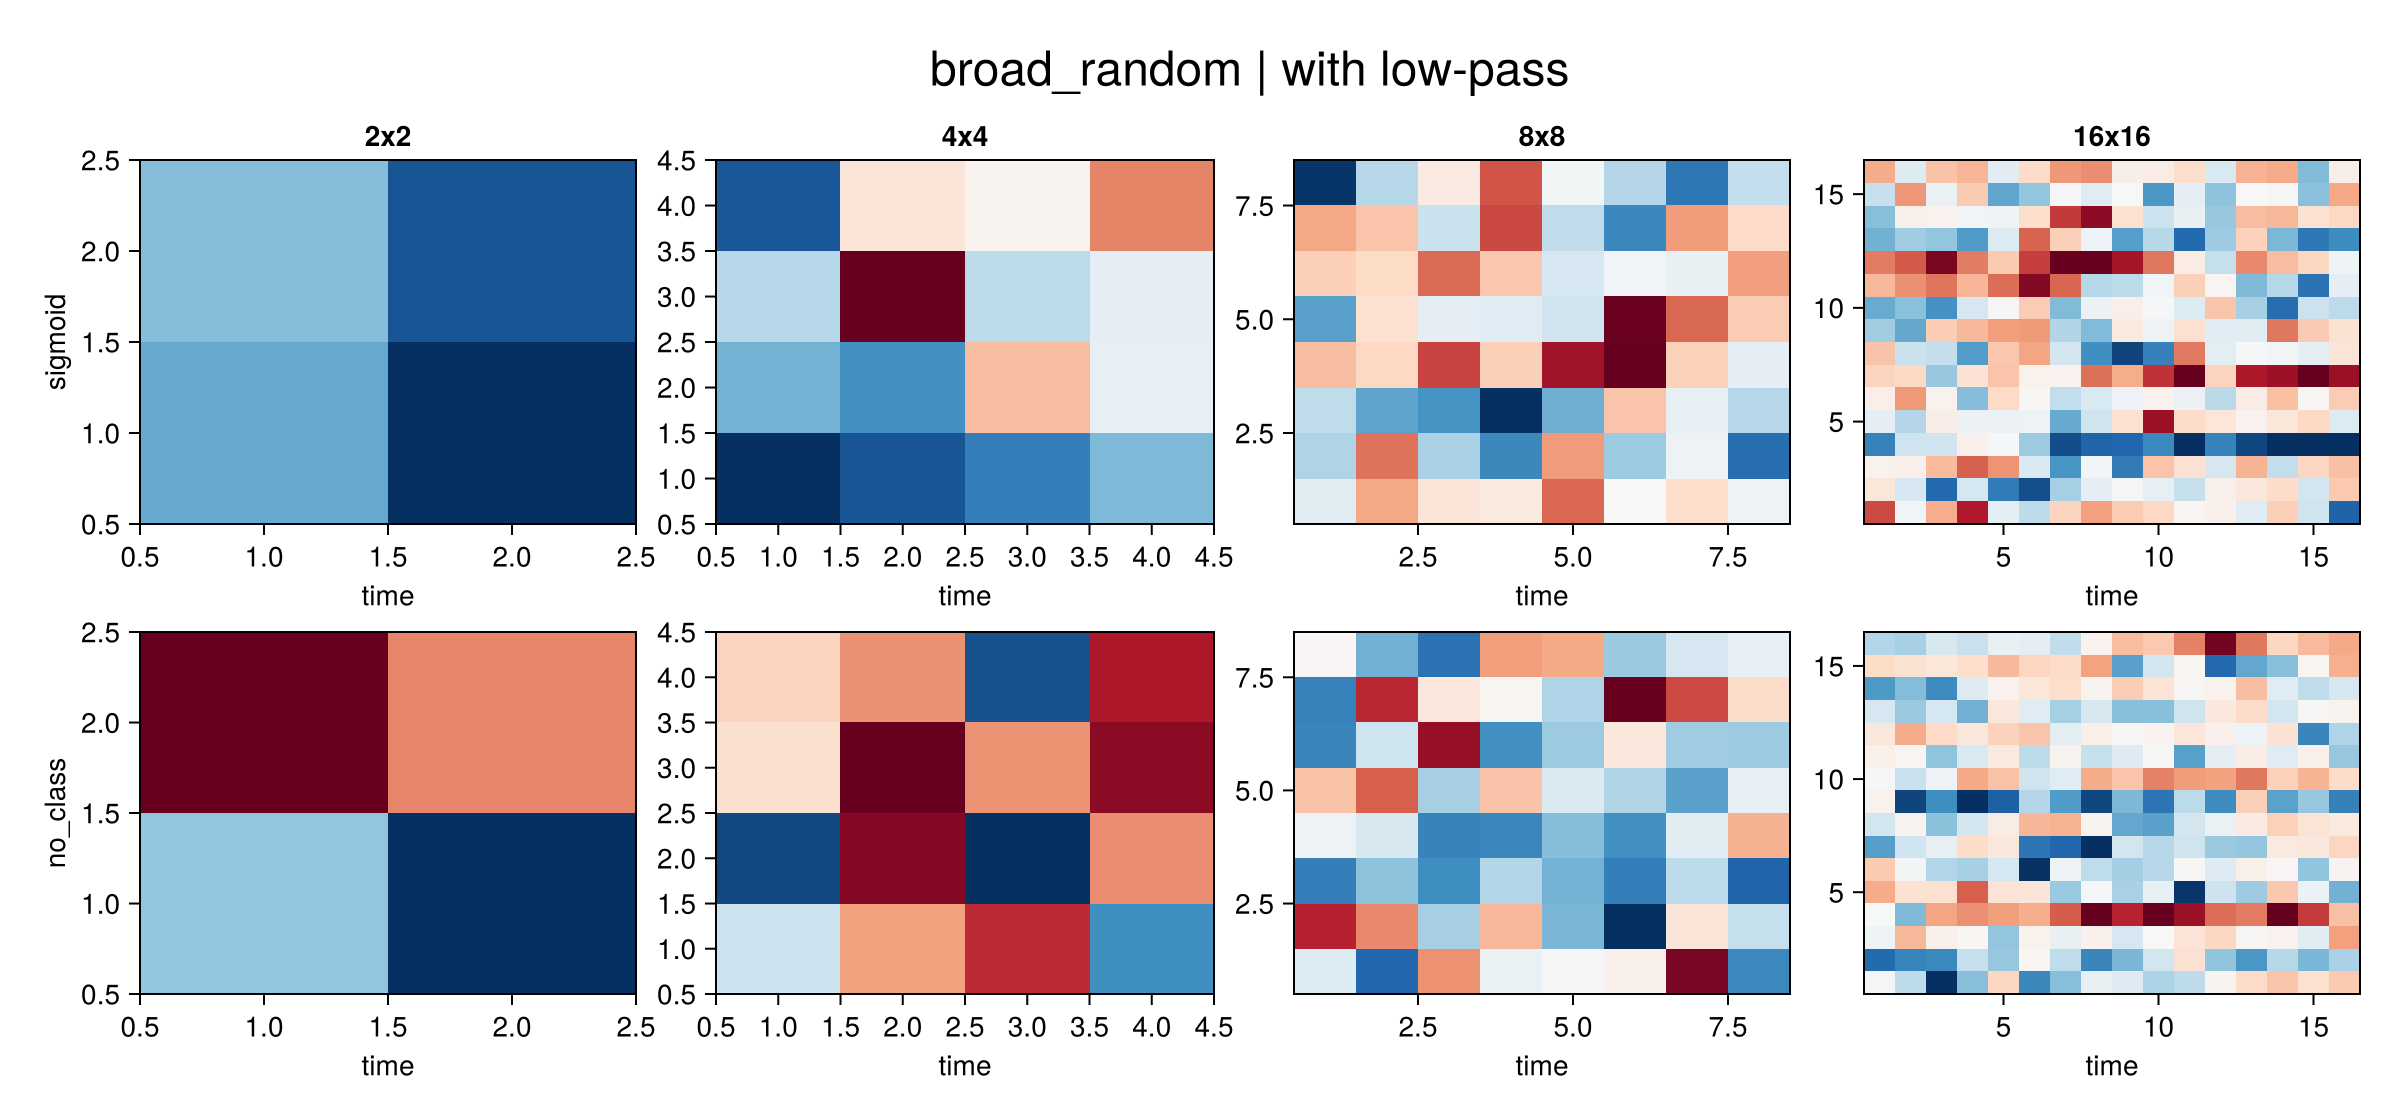

In [10]:
# Plot example simulated images for the best strategy (with low-pass).
#
# Shows one sigmoid and one no_class image per resolution (2x2 to 16x16).
# This is a quick visual sanity check: does the simulated sigmoid structure
# look like a plausible ERP image, and does no_class look unstructured?
plot_example_images(experiment.simulated_cache, Symbol(best_strategy_name); lowpass = true)


## Confusion Example Diagnostics

This section moves from aggregate metrics to **concrete real examples**.
The idea is simple: a good score alone does not tell you *why* the model behaves the way it does.
To understand that, we inspect one real example for each confusion-matrix category:

- `TP`: real `sigmoid`, predicted `sigmoid`
- `TN`: real `no_class`, predicted `no_class`
- `FP`: real `no_class`, predicted `sigmoid`
- `FN`: real `sigmoid`, predicted `no_class`

How the section works:
- the first code cell reconstructs predictions for a high-ranked setting and tries to find a case where all four categories exist
- the second code cell randomly samples one example from each category and plots them with their own colorbar

Why this matters:
- `TP` and `TN` show what the model handles well
- `FP` shows what kind of non-sigmoid structure is mistakenly considered signal-like
- `FN` shows which real `sigmoid` cases are too weak, noisy, or structurally different from the learned simulator prior

How to use the section:
- first inspect the metadata and counts table to understand what configuration was replayed
- then inspect the actual plotted examples
- if you want a different set of examples from the same replayed model, re-run only the plot cell

This section is intentionally diagnostic, not competitive.
Its purpose is to explain model behavior, not to produce a better score.


In [11]:
# Reconstruct one high-ranked model result and prepare TP/TN/FP/FN diagnostics.
#
# What this cell does:
# - it replays a selected ranked result
# - it stores the predictions and confusion-matrix category indices
# - it summarizes how many examples are available in each category
#
# Why it matters:
# aggregate metrics alone do not reveal what the model confuses in concrete terms.
best_confusion_bundle = build_confusion_example_bundle(
    experiment;
    ranked_results = result_tables.ranked,
    prefer_complete_confusion = true,
    nn_batch_size = NN_BATCH_SIZE,
    nn_epochs = NN_EPOCHS,
    nn_lr = NN_LR,
    rf_trees = RF_TREES,
    seed = BASE_SEED,
)

confusion_config_df = DataFrame([merge(
    best_confusion_bundle.selected_config,
    (
        complete_confusion = best_confusion_bundle.complete_confusion,
        prefer_complete_confusion = best_confusion_bundle.prefer_complete_confusion,
    ),
)])

confusion_counts_df = DataFrame(
    category = ["TP", "TN", "FP", "FN"],
    count = [
        best_confusion_bundle.counts.tp,
        best_confusion_bundle.counts.tn,
        best_confusion_bundle.counts.fp,
        best_confusion_bundle.counts.fn,
    ],
)

display(confusion_config_df)
confusion_counts_df


    dense_nn epoch 1/30 | loss=0.5919
    dense_nn epoch 6/30 | loss=0.08325
    dense_nn epoch 12/30 | loss=0.03664
    dense_nn epoch 18/30 | loss=0.01607
    dense_nn epoch 24/30 | loss=0.02181
    dense_nn epoch 30/30 | loss=0.01823


Row,rank,strategy,resolution,target_size,lowpass,model,balanced_accuracy,macro_f1,n_train,n_real,complete_confusion,prefer_complete_confusion
,Int64,String,String,Tuple…,Bool,String,Float64,Float64,Int64,Int64,Bool,Bool
1,1,mc_random_search,16x16,"(16, 16)",true,dense_nn_gpu,0.684489,0.542166,2000,488,true,true


Row,category,count
,String,Int64
1,TP,23
2,TN,330
3,FP,122
4,FN,13


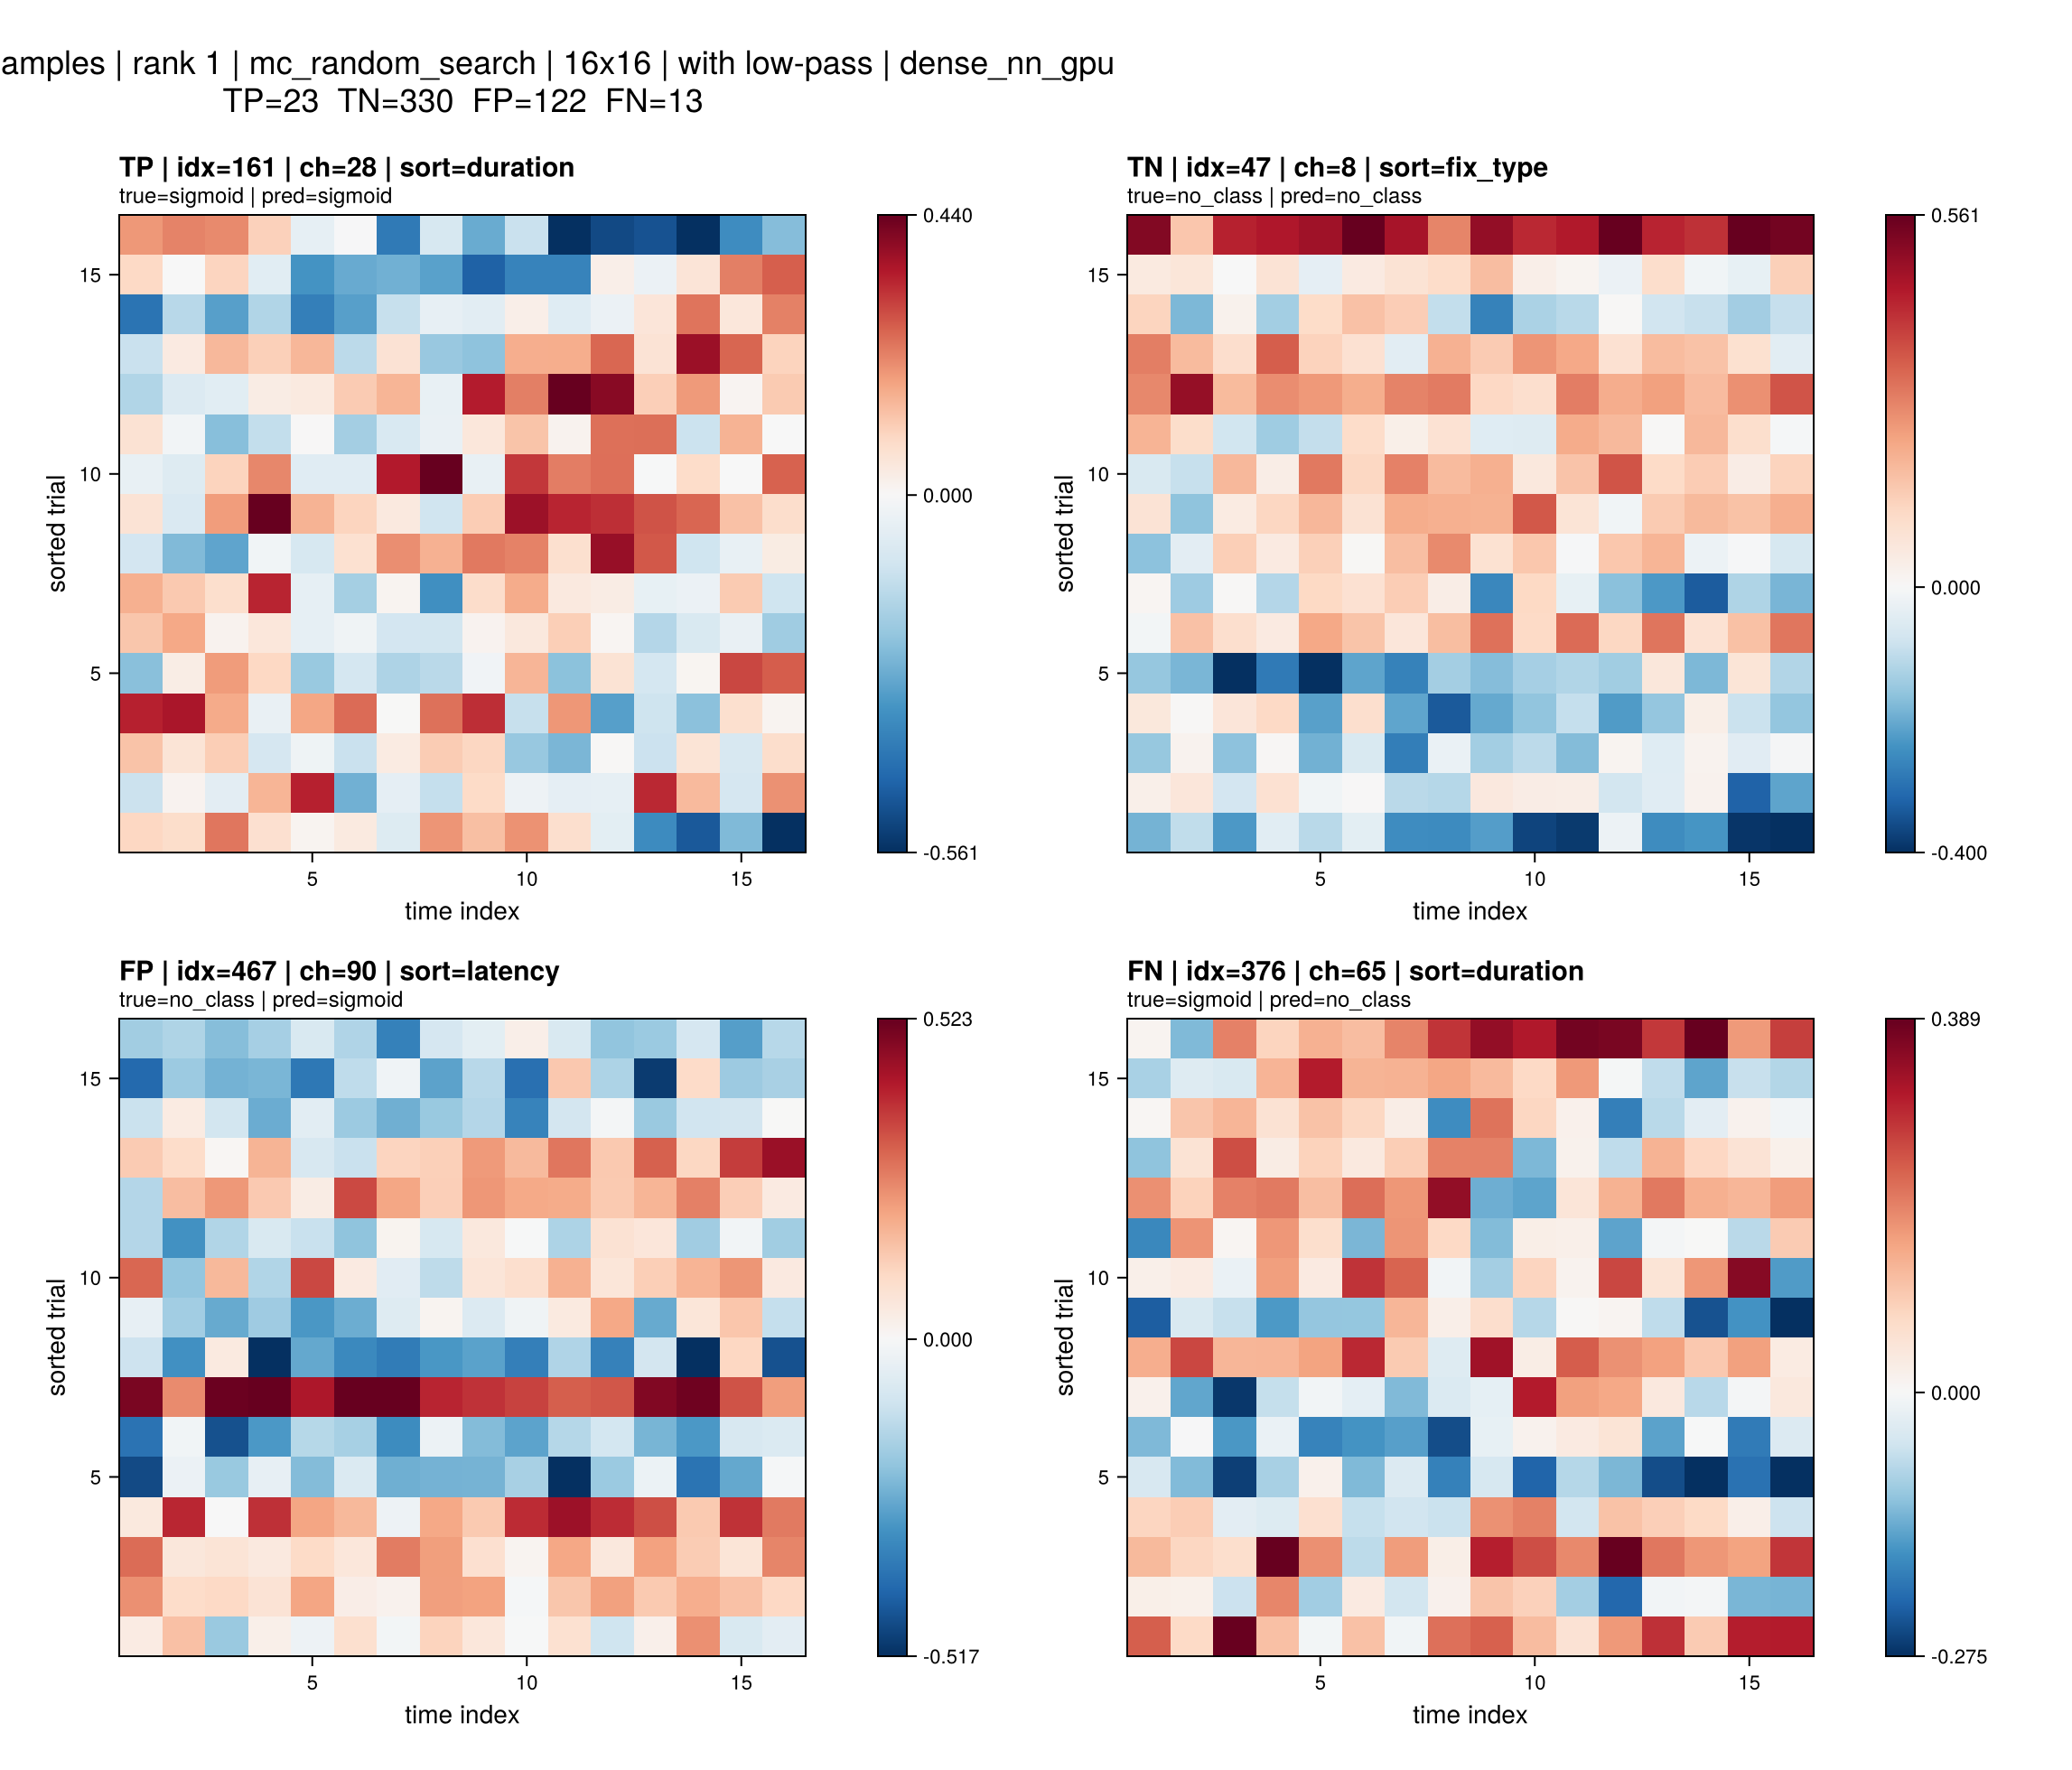

In [12]:
plot_confusion_examples(best_confusion_bundle)


## Dense NN Low-Pass Direct Search

This section was moved to the standalone notebook `dense_nn_lowpass_direct_search.ipynb` in the same folder.

Why it was split out:
- the direct Dense-NN search is now a separate model-first workflow
- it no longer reuses top settings from the simulator-first notebook
- `broad_random`, `latin_hypercube`, and `monte_carlo` now search directly for high real-data `balanced_accuracy`

Open the companion notebook when you want to optimize Dense-NN low-pass performance on the real labeled data.
